In [1]:
import os
import fastplotlib as fpl
import sys
import masknmf
import tifffile
import torch
import numpy as np

import matplotlib.pyplot as plt
import time
from typing import *
import pathlib
from pathlib import Path

import math
%load_ext line_profiler
%matplotlib inline
%load_ext autoreload

libEGL warning: DRI2: failed to authenticate


Image(value=b'version https://git-lfs.github.com/spec/...', height='55', width='300')

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A6000,DiscreteGPU,Vulkan,560.35.03
❗ limited,"llvmpipe (LLVM 15.0.7, 256 bits)",CPU,Vulkan,Mesa 23.2.1-1ubuntu3.1~22.04.3 (LLVM 15.0.7)
❌,"llvmpipe (LLVM 15.0.7, 256 bits)",CPU,OpenGL,4.5 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.3


In [22]:
datafile = np.load("/mnt/data1/vps2116/Widefield_MtlabOutputs/cm9999/cm9999_7_Registration/run7C_compressed_denoised_masked_blood.npz", allow_pickle = True)

In [10]:
pmd_obj = datafile['pmd_denoise'].item()
sliced_obj = pmd_obj[8700:9300]

In [11]:
pmd_obj.rescale = False
pmd_obj.to('cuda')
pmd_obj.shape

(17970, 254, 254)

In [4]:
import os
my_mask = np.load('/mnt/data1/vps2116/Widefield_MtlabOutputs/cm9999/cm9999_17_Registration/brain_mask_7.npy')

my_mask.shape

(256, 256)

In [21]:
#cropped mask version
import os
import numpy as np

my_mask = np.load(
    '/mnt/data1/vps2116/Widefield_MtlabOutputs/cm9999/cm9999_7_Registration/brain_mask_7.npy'
)
print("Original mask shape:", my_mask.shape)  # (256, 256)

# Crop 1-pixel border on all sides → (254, 254)
my_mask = my_mask[1:-1, 1:-1]
print("Cropped mask shape:", my_mask.shape)  # (254, 254)

def make_init(mask, num_comps):
    array_list = []
    for k in range(num_comps):
        x = mask.astype(np.float32) * np.random.rand(mask.shape[0], mask.shape[1])
        array_list.append(x)
    return np.array(array_list).transpose(1, 2, 0)  # (H, W, K)

num_components_to_init = 10
a_init = make_init(my_mask, num_components_to_init)
print("a_init shape:", a_init.shape)  # (254, 254, 10)


Original mask shape: (256, 256)
Cropped mask shape: (254, 254)
a_init shape: (254, 254, 10)


In [28]:
# --- PCA (via SVD) on masked pixels, frames 1:17000 or set to stimulus frames 8700-9300 ---

import numpy as np

# 1) Pull the data to NumPy and slice time
# pmd_obj shape (T, H, W) per your printout: (17970, 256, 256)
# If pmd_obj lives on GPU (e.g., CuPy), try to bring it to host.
arr = pmd_obj[0:17000]  # (T_slice, H, W)

# Try to coerce to NumPy safely
try:
    arr_np = np.asarray(arr)
except Exception:
    # fall back: some GPU arrays support .get() to pull to host
    arr_np = arr.get()

T, H, W = arr_np.shape
mask = (my_mask > 0)  # boolean mask (H, W)
P = mask.sum()
print(f"SVD on frames: {T}, masked pixels: {P} / {H*W}")

# 2) Build data matrix X with shape (T, P): rows=time, cols=pixels
X = arr_np[:, mask]  # (T, P)

# 3) Mean subtract *each pixel* across time so components have PCA meaning
pixel_means = X.mean(axis=0, keepdims=True)   # (1, P)
Xc = X - pixel_means

# (Optional) save total variance for sanity checks
total_var = (Xc**2).sum() / (T - 1)

# 4) SVD (economy). For memory, cast to float32 if needed.
Xc32 = Xc.astype(np.float32, copy=False)
U, S, VT = np.linalg.svd(Xc32, full_matrices=False)
# U: (T, K), S: (K,), VT: (K, P), where K = min(T, P)

# 5) PCA quantities
# explained variance of each component: S^2 / (T - 1)
explained_variance = (S.astype(np.float64)**2) / (T - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# temporal scores (timecourses) = U * S
scores_time = U * S  # shape (T, K)

# spatial components ("eigenimages") are rows of VT mapped back into (H, W)
K = VT.shape[0]
components_maps = np.zeros((K, H, W), dtype=np.float32)
components_maps[:, mask] = VT.astype(np.float32)

# 6) Handy outputs:
# - scores_time[:, i]         -> i-th component timecourse
# - components_maps[i, ...]   -> i-th component spatial map (eigenimage)
# - explained_variance_ratio  -> per-component variance fraction
# - cumulative_variance_ratio -> cumulative variance fraction

print("Top 10 explained variance ratios:")
print(explained_variance_ratio[:10])
print("Cumulative (top 10):")
print(cumulative_variance_ratio[:10])


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.09 GiB. GPU 0 has a total capacity of 47.43 GiB of which 2.29 GiB is free. Process 117139 has 21.97 GiB memory in use. Including non-PyTorch memory, this process has 8.55 GiB memory in use. Process 230779 has 14.53 GiB memory in use. Of the allocated memory 8.23 GiB is allocated by PyTorch, and 19.33 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [26]:

#Z-scored version

# --- PCA (via SVD) on masked pixels, with per-pixel Z-scoring and optional even-frames (internal control)---

import numpy as np

# ----- CONFIG -----
use_even_frames = False  # <-- set True to run PCA on even-numbered frames only (every other frame)
t0, t1 = 0, 17000      # your original time slice [t0:t1)

# 1) Pull the data to NumPy and slice time
# pmd_obj shape (T, H, W) per your printout: (17970, 256, 256)
arr = pmd_obj[t0:t1]  # (T_slice, H, W)

# Try to coerce to NumPy safely
try:
    arr_np = np.asarray(arr)
except Exception:
    # fall back: some GPU arrays support .get() to pull to host
    arr_np = arr.get()

# Optionally keep only even frames (relative to this sliced window)
# This takes every other frame: arr_np[0], arr_np[2], arr_np[4], ...
if use_even_frames:
    arr_np = arr_np[::2]

T, H, W = arr_np.shape
mask = (my_mask > 0)  # boolean mask (H, W)
P = int(mask.sum())
print(f"SVD on frames: {T}, masked pixels: {P} / {H*W}")

# 2) Build data matrix X with shape (T, P): rows=time, cols=pixels
X = arr_np[:, mask]  # (T, P)

# 3) Z-score *each pixel* across time (mean 0, std 1 per column)
#    Use ddof=1 for sample std; protect against zero-std columns.
pixel_means = X.mean(axis=0, keepdims=True)                         # (1, P)
pixel_stds  = X.std(axis=0, ddof=1, keepdims=True)                  # (1, P)
eps = 1e-8
Xz = (X - pixel_means) / np.maximum(pixel_stds, eps)                # (T, P)

# (Optional) total variance sanity check (should be ~P after z-scoring, up to small rounding):
total_var = (Xz**2).sum() / (T - 1)
# print(f"Total variance after z-scoring (should be ~P): {total_var:.3f}")

# 4) SVD (economy). For memory, cast to float32 if needed.
Xz32 = Xz.astype(np.float32, copy=False)
U, S, VT = np.linalg.svd(Xz32, full_matrices=False)
# U: (T, K), S: (K,), VT: (K, P), where K = min(T, P)

# 5) PCA quantities
# explained variance of each component (correlation-PCA since we standardized):
# Var_i = S_i^2 / (T - 1)
explained_variance = (S.astype(np.float64)**2) / (T - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# temporal scores (timecourses) = U * S
scores_time = U * S  # shape (T, K)

# spatial components ("eigenimages") are rows of VT mapped back into (H, W)
K = VT.shape[0]
components_maps = np.zeros((K, H, W), dtype=np.float32)
components_maps[:, mask] = VT.astype(np.float32)

# 6) Handy outputs:
# - scores_time[:, i]         -> i-th component timecourse
# - components_maps[i, ...]   -> i-th component spatial map (eigenimage)
# - explained_variance_ratio  -> per-component variance fraction
# - cumulative_variance_ratio -> cumulative variance fraction

print("Top 10 explained variance ratios:")
print(explained_variance_ratio[:10])
print("Cumulative (top 10):")
print(cumulative_variance_ratio[:10])


SVD on frames: 7000, masked pixels: 18542 / 64516
Top 10 explained variance ratios:
[0.77856626 0.0922201  0.05202314 0.02447602 0.01712287 0.01083859
 0.00466093 0.00381635 0.00280793 0.00198575]
Cumulative (top 10):
[0.77856626 0.87078635 0.92280949 0.94728551 0.96440838 0.97524697
 0.9799079  0.98372425 0.98653218 0.98851794]


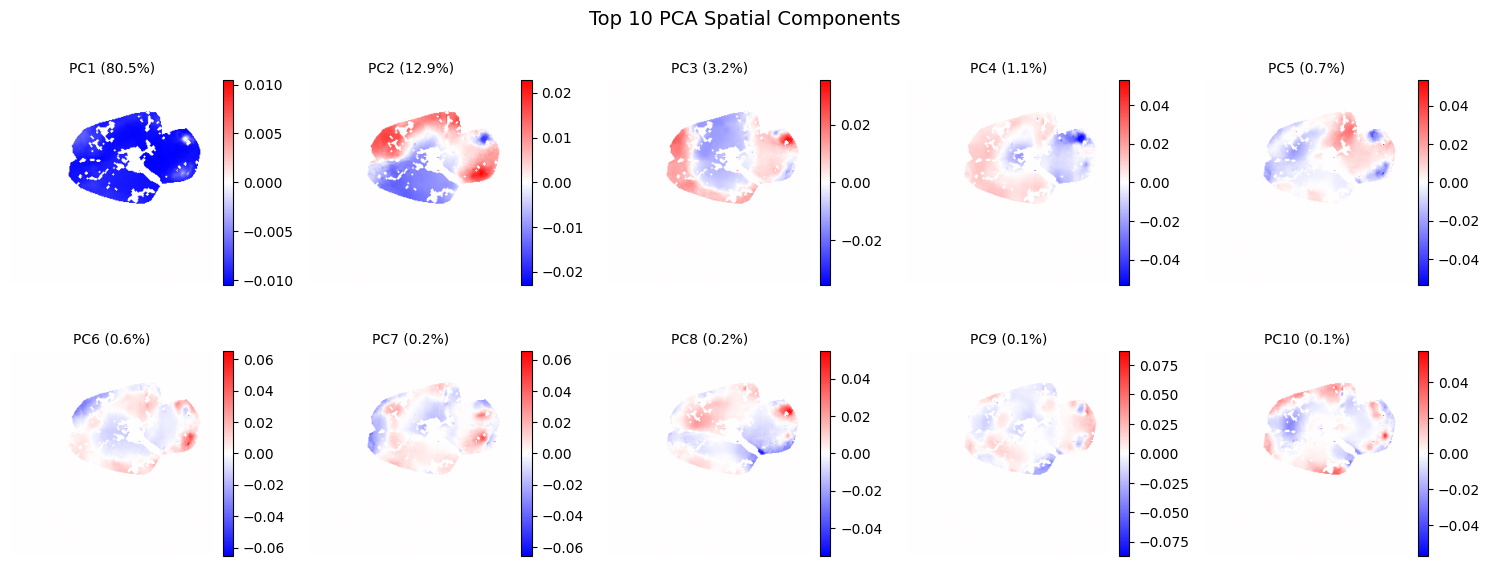

In [19]:
import matplotlib.pyplot as plt

# Plot top 10 spatial components
n_comps = 10
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(n_comps):
    im = axes[i].imshow(components_maps[i], cmap='bwr', vmin=-np.max(np.abs(components_maps[i])), vmax=np.max(np.abs(components_maps[i])))
    axes[i].set_title(f"PC{i+1} ({explained_variance_ratio[i]*100:.1f}%)", fontsize=10)
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle("Top 10 PCA Spatial Components", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
#Improved Contrast Visualization
import numpy as np
import matplotlib.pyplot as plt

# Plot top 10 spatial components with adaptive contrast
n_comps = 10
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(n_comps):
    comp = components_maps[i]

    # Use the 99th percentile of |values| to avoid outlier-driven ranges
    base_max = np.percentile(np.abs(comp), 99)

    # Adaptive scaling:
    # - PC1: tighter range (stronger contrast)
    # - PCs 2–5: normal
    # - PCs 6–10: tighter range (darker colors, more saturation)
    if i == 0:
        scale = 0.75   # increase contrast on PC1
    elif i < 5:
        scale = 0.95   # near-original scaling
    else:
        scale = 0.55   # boost contrast on later PCs

    vmax = base_max * scale
    vmin = -vmax

    im = axes[i].imshow(
        comp,
        cmap='bwr',
        vmin=vmin,
        vmax=vmax,
        interpolation='nearest'
    )
    axes[i].set_title(f"PC{i+1} ({explained_variance_ratio[i]*100:.1f}%)", fontsize=10)
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle("Top 10 PCA Spatial Components", fontsize=14)
plt.tight_layout()
plt.show()


In [37]:
# --- Interactive viewer for PCA spatial components ---

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Assumes you already have:
# components_maps: (K, H, W)
# explained_variance_ratio: (K,)

K = components_maps.shape[0]

# Widgets
# Widgets
pc_slider = widgets.IntSlider(value=0, min=0, max=K-1, step=1, description='PC', continuous_update=False)
play = widgets.Play(interval=2000, value=0, min=0, max=K-1, step=1, description="")  # fixed
widgets.jslink((play, 'value'), (pc_slider, 'value'))


scale_mode = widgets.ToggleButtons(
    options=[('Per-component', 'per'), ('Global', 'global')],
    value='per', description='Scale:'
)

# Use a robust global limit (99.5% of abs values) to avoid outliers
global_vmax_default = float(np.percentile(np.abs(components_maps), 99.5))
global_vmax = widgets.FloatSlider(
    value=global_vmax_default, min=global_vmax_default/10, max=global_vmax_default*5,
    step=global_vmax_default/100, readout_format='.3g', description='Global vmax'
)

out = widgets.Output()

def redraw(*_):
    i = pc_slider.value
    img = components_maps[i]

    if scale_mode.value == 'per':
        m = float(np.max(np.abs(img))) or 1.0
    else:
        m = float(global_vmax.value) or 1.0

    with out:
        out.clear_output(wait=True)
        plt.figure(figsize=(5,5))
        plt.imshow(img, cmap='bwr', vmin=-m, vmax=m)
        plt.title(f"PC {i+1}/{K} — variance: {explained_variance_ratio[i]*100:.2f}%")
        plt.axis('off')
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.show()

# Wire up events
pc_slider.observe(redraw, 'value')
scale_mode.observe(redraw, 'value')
global_vmax.observe(redraw, 'value')

# Initial draw + layout
redraw()
widgets.VBox([
    widgets.HBox([play, pc_slider]),
    scale_mode,
    global_vmax,
    out
])


In [38]:
# --- Interactive viewer for PCA spatial components + temporal traces (with Fix A) ---

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Assumes you already have:
# components_maps: (K, H, W)
# explained_variance_ratio: (K,)
# scores_time: (T, K)

# If you don't have scores_time_z yet, compute it here
try:
    _ = scores_time_z
except NameError:
    scores_time_z = (scores_time - scores_time.mean(axis=0, keepdims=True)) / (
        scores_time.std(axis=0, ddof=1, keepdims=True) + 1e-12
    )

K = components_maps.shape[0]
T = scores_time.shape[0]

# ------------------ Widgets ------------------
pc_slider = widgets.IntSlider(value=0, min=0, max=K-1, step=1,
                              description='PC', continuous_update=False)
play = widgets.Play(interval=1000, value=0, min=0, max=K-1, step=1, description="")
widgets.jslink((play, 'value'), (pc_slider, 'value'))

scale_mode = widgets.ToggleButtons(
    options=[('Per-component', 'per'), ('Global', 'global')],
    value='per', description='Scale:'
)

# robust global limit for spatial color scaling
global_vmax_default = float(np.percentile(np.abs(components_maps), 99.5))
global_vmax = widgets.FloatSlider(
    value=global_vmax_default, min=global_vmax_default/10, max=global_vmax_default*5,
    step=max(global_vmax_default/100, 1e-6), readout_format='.3g', description='Global vmax'
)

# trace controls
trace_mode = widgets.ToggleButtons(
    options=[('Raw', 'raw'), ('Z-scored', 'z')],
    value='z', description='Trace:'
)

frame_range = widgets.IntRangeSlider(
    value=(0, min(T-1, 17000)), min=0, max=T-1, step=1,
    description='Frames', continuous_update=False
)

# Output with fixed height to avoid flashing blank
out = widgets.Output()
out.layout = widgets.Layout(min_height='420px')  # <-- Fix A

# ------------------ Draw ------------------
def redraw(*_):
    i = pc_slider.value
    img = components_maps[i]

    # spatial scaling
    if scale_mode.value == 'per':
        m = float(np.max(np.abs(img))) or 1.0
    else:
        m = float(global_vmax.value) or 1.0

    # temporal trace selection
    a, b = frame_range.value
    if trace_mode.value == 'raw':
        trace = scores_time[a:b+1, i]
        ylab = 'PC timecourse (raw)'
    else:
        trace = scores_time_z[a:b+1, i]
        ylab = 'PC timecourse (z)'

    x = np.arange(a, b+1)

    with out:
        out.clear_output(wait=True)  # still safe, height is reserved
        fig = plt.figure(figsize=(11,5))

        # left: spatial component
        ax1 = fig.add_subplot(1,2,1)
        im = ax1.imshow(img, cmap='bwr', vmin=-m, vmax=m)
        ax1.set_title(f"PC {i+1}/{K} — {explained_variance_ratio[i]*100:.2f}% var")
        ax1.axis('off')
        fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

        # right: temporal trace
        ax2 = fig.add_subplot(1,2,2)
        ax2.plot(x, trace, lw=0.8)
        ax2.set_xlabel('Frame')
        ax2.set_ylabel(ylab)
        ax2.set_title('Temporal trace')
        ax2.grid(True, linestyle='--', alpha=0.4)

        plt.tight_layout()
        plt.show()

# ------------------ Wire up ------------------
pc_slider.observe(redraw, 'value')
scale_mode.observe(redraw, 'value')
global_vmax.observe(redraw, 'value')
trace_mode.observe(redraw, 'value')
frame_range.observe(redraw, 'value')

# Initial draw + layout
redraw()
widgets.VBox([
    widgets.HBox([play, pc_slider]),
    widgets.HBox([scale_mode, global_vmax, trace_mode]),
    frame_range,
    out
])


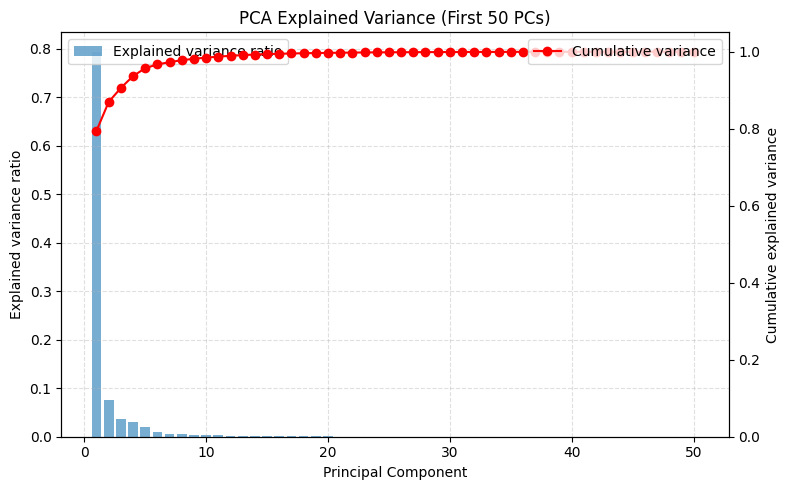

In [39]:
import matplotlib.pyplot as plt
import numpy as np
# Limit to first N components for clarity
N = 50  # adjust to see more or fewer PCs
x = np.arange(1, N+1)

fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar plot: variance ratio per component
ax1.bar(x, explained_variance_ratio[:N], alpha=0.6, label='Explained variance ratio')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained variance ratio')
ax1.set_title(f'PCA Explained Variance (First {N} PCs)')
ax1.grid(True, linestyle='--', alpha=0.4)

# Line plot: cumulative variance
ax2 = ax1.twinx()
ax2.plot(x, np.cumsum(explained_variance_ratio[:N]), color='red', marker='o', label='Cumulative variance')
ax2.set_ylabel('Cumulative explained variance')
ax2.set_ylim(0, 1.05)

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()



In [40]:
target_var = 0.95
rank_95 = np.argmax(np.cumsum(explained_variance_ratio) >= target_var) + 1
print(f"Smallest number of PCs for ≥95% variance explained: {rank_95}")


Smallest number of PCs for ≥95% variance explained: 5


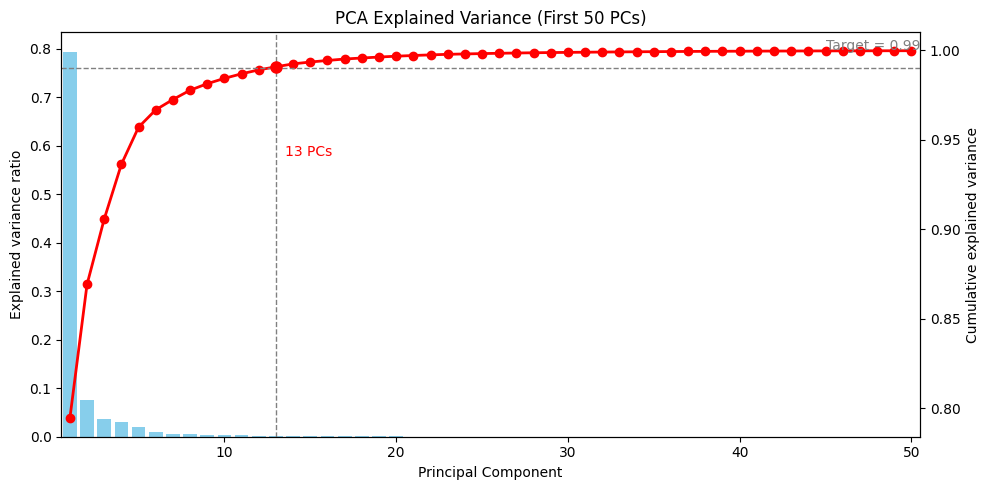

In [41]:
import numpy as np
import matplotlib.pyplot as plt

target_var = 0.99
show_first = 50

evr = np.asarray(explained_variance_ratio)
cum = np.cumsum(evr)
K = min(show_first, evr.size)

idx_reach = np.argmax(cum >= target_var) if np.any(cum >= target_var) else None

fig, ax = plt.subplots(figsize=(10,5))

# bar plot: per-PC explained variance
ax.bar(np.arange(1, K+1), evr[:K], color="skyblue", edgecolor="none")

# line plot: cumulative variance (red)
ax2 = ax.twinx()
ax2.plot(np.arange(1, K+1), cum[:K], 'o-', color='red', lw=2)

# target line
ax2.axhline(target_var, ls='--', color='gray', lw=1)
ax2.text(K-5, target_var+0.01, f"Target = {target_var:.2f}", color='gray')

# mark the point where target is reached
if idx_reach is not None:
    k_hit = idx_reach + 1
    ax2.axvline(k_hit, ls='--', color='gray', lw=1)
    ax2.plot([k_hit], [cum[idx_reach]], 'o', color='red', ms=8)
    ax2.text(k_hit+0.5, cum[idx_reach]-0.05,
             f"{k_hit} PCs", color='red')

# axis settings
ax.set_xlim(0.5, K+0.5)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained variance ratio")
ax2.set_ylabel("Cumulative explained variance")

ax.set_title(f"PCA Explained Variance (First {K} PCs)")

plt.tight_layout()
plt.show()
